## Settings & imports

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from matplotlib.lines import Line2D
import string
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import csv
import pickle
import re

In [2]:
dataset = 'Konstytucja_indicators'
book_name = 'all'

In [3]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

which_dataset = config["which_dataset"]
preprocessing_method = config["preprocessing_method"] # normalization / logarithm
remove_outer_bool = config["remove_outer"]
how_many_outer_to_remove = config["how_many_outer_to_remove"]
elements_to_keep = config["elements_to_keep"][which_dataset]
elements_to_keep_xrf = config["elements_to_keep_xrf"]

data_path = config["data_path"][which_dataset]
target_path = config["target_path"][which_dataset]
figures_path = config["figures_path"]
models_path = config["models_path"][which_dataset]
classes_path = config["classes_path"]
Konstytucja_results_path = config["Konstytucja_results_path"][which_dataset]
xrf_path = config["xrf_path"]

In [4]:
marker_shapes = {'AS' : 'v', 'AP': 'd', 'ML': '*'}

## Loading the data & preprocessing

In [5]:
if dataset == 'Konstytucja_indicators':
    input_data = np.loadtxt(target_path, delimiter=',', skiprows=1, usecols=range(19))
    colnames = pd.read_csv(target_path, nrows=1, header=None)
    df = pd.DataFrame(data=input_data, columns=colnames.iloc[0,:-1])
    df = df[elements_to_keep]
elif dataset == 'Konstytucja_prediction':
    input_data = np.loadtxt(Konstytucja_results_path, delimiter=',')
    df = pd.DataFrame(data=input_data, columns=elements_to_keep)
elif dataset == 'XRF':
    input_data = np.loadtxt(xrf_path, delimiter=',', skiprows=1, usecols=(2,3,4))
    df = pd.DataFrame(data=input_data, columns=elements_to_keep_xrf)

df.reset_index(drop=True, inplace=True)

In [6]:
classes_df = pd.read_excel(classes_path, header=1, usecols=['NAZWA', 'OPIS'])
classes_df['NAZWA_short'] = classes_df['NAZWA'].apply(lambda x: 
                                                    re.split(r'(\d+)', x)[0] + re.split(r'(\d+)', x)[1] if len(re.split(r'(\d+)', x))>1 else re.split(r'(\d+)', x)[0]
                                                   )                                                    
classes_df.drop_duplicates(['NAZWA', 'OPIS'], inplace=True)
classes_df_supp = classes_df.drop_duplicates(['NAZWA_short'])
classes_df_supp['NAZWA'] = classes_df['NAZWA_short']
classes_df = pd.concat([classes_df, classes_df_supp])
classes_df.drop_duplicates(inplace=True)
classes_df.reset_index(inplace=True, drop=True)

/tmp/ipykernel_17120/3014040627.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  classes_df_supp['NAZWA'] = classes_df['NAZWA_short']


In [7]:
def remove_outer(group, n):
    return group.iloc[n:-n] if len(group) > 2*n else pd.DataFrame(columns=group.columns)

In [8]:
########################################################

In [9]:
if dataset == 'Konstytucja_indicators' or dataset == 'Konstytucja_prediction':
    
    if which_dataset == 'old':
        ground_truth_df = pd.read_csv(target_path, usecols=['probka', 'short'])
        ground_truth_df.rename(columns={"probka": "Sample_id"}, inplace=True)
    elif which_dataset == 'new':
        ground_truth_df = pd.read_csv(target_path, usecols=['name'])
        ground_truth_df['Sample_id'] = ground_truth_df['name'].apply(lambda x: x.split('_')[0] if len(x.split('_'))==2 else x.split('_')[0] + x.split('_')[1])
        ground_truth_df['Sample_id'] = ground_truth_df['Sample_id'].apply(lambda x: x.replace('.', ''))
        ground_truth_df['short'] = ground_truth_df['Sample_id'].apply(lambda x: re.split(r'\d+', x)[0])
        ground_truth_df.drop(columns=['name'], inplace=True)
    
    ground_truth_df.reset_index(drop=True, inplace=True)
    
    if remove_outer_bool:
        ground_truth_df = ground_truth_df.groupby('Sample_id', group_keys=False).apply(remove_outer, n=how_many_outer_to_remove)

elif dataset == 'XRF':

    ground_truth_df = pd.read_csv(xrf_path, usecols=['name'])
    ground_truth_df.rename(columns={'name': 'Sample_id'}, inplace=True)
    ground_truth_df['short'] = ground_truth_df['Sample_id'].apply(lambda x: re.split(r'\d+', x)[0])

In [10]:
ground_truth_df = pd.merge(left=ground_truth_df, right=classes_df, how='left', left_on='Sample_id', right_on='NAZWA')
    
ground_truth_df['OPIS'] = ground_truth_df['OPIS'].apply(lambda x: str(x).strip())
ground_truth_df.drop(columns=['NAZWA', 'NAZWA_short'], inplace=True)
ground_truth_df.reset_index(drop=True, inplace=True)

### Dividing to APP, ASC, ML

In [11]:
df_app = df[ground_truth_df['short'].apply(lambda x: x.startswith('APP'))]
df_asc = df[ground_truth_df['short'].apply(lambda x: x.startswith('ASC'))]
df_ml = df[ground_truth_df['short'].apply(lambda x: x.startswith('ML'))]

if book_name == 'app':
    df = df_app
elif book_name == 'asc':
    df = df_asc
elif book_name == 'ml':
    df = df_ml
elif book_name == 'all':
    pass

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [12]:
if dataset == 'Konstytucja_indicators' or dataset == 'Konstytucja_prediction':
    df = df[elements_to_keep]

2. Let's check if there are any rows with missing values.

In [13]:
(df.shape[0] - df.dropna().shape[0])/df.shape[0]

0.0

3. Let's reset index.

In [14]:
df.reset_index(drop=True, inplace=True)

### Converting to np.array

In [15]:
X = np.array(df.values)

### Normalizing / taking logarithm

In [16]:
def adjusted_log_transform(input_array):
    res = np.where(input_array>0, np.log(input_array), 0.)
    return res

In [17]:
if dataset == 'Konstytucja_indicators' or dataset == 'Konstytucja_prediction':

    if preprocessing_method == 'normalization':
    
        X = (X - np.min(X, axis=0))/np.std(X, axis=0)
        
    elif preprocessing_method == 'logarithm':
        
        X = adjusted_log_transform(X)
    
    elif preprocessing_method == 'logarithm_and_normalization':
        
        #logarithm
        X = adjusted_log_transform(X)
        
        #normalization
        X = (X - np.min(X, axis=0))/np.std(X, axis=0)
        
    elif preprocessing_method == 'none':
        
        pass

### Ground truth

In [18]:
class_df_app = ground_truth_df[ground_truth_df['short'].apply(lambda x: x.startswith('APP'))][['Sample_id','OPIS']]
class_df_asc = ground_truth_df[ground_truth_df['short'].apply(lambda x: x.startswith('ASC'))][['Sample_id', 'OPIS']]
class_df_ml = ground_truth_df[ground_truth_df['short'].apply(lambda x: x.startswith('ML'))][['Sample_id', 'OPIS']]

if book_name == 'app':
    class_df = class_df_app
elif book_name == 'asc':
    class_df = class_df_asc
elif book_name == 'ml':
    class_df = class_df_ml
elif book_name == 'all':
    class_df = ground_truth_df[['Sample_id', 'OPIS']]

class_df.columns = ['Code', 'Class name']

In [19]:
y = class_df['Class name']
y = [str(y) for y in y]
class_df.reset_index(inplace=True, drop=True)

### PCA - all points

In [20]:
from sklearn.decomposition import PCA

n_components = 2
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

In [21]:
#%matplotlib widget

In [22]:
signatures = [word for word in sorted(list(set(y))) if 'podpis' in word]
other = sorted(list(set(y).difference(set(signatures))))

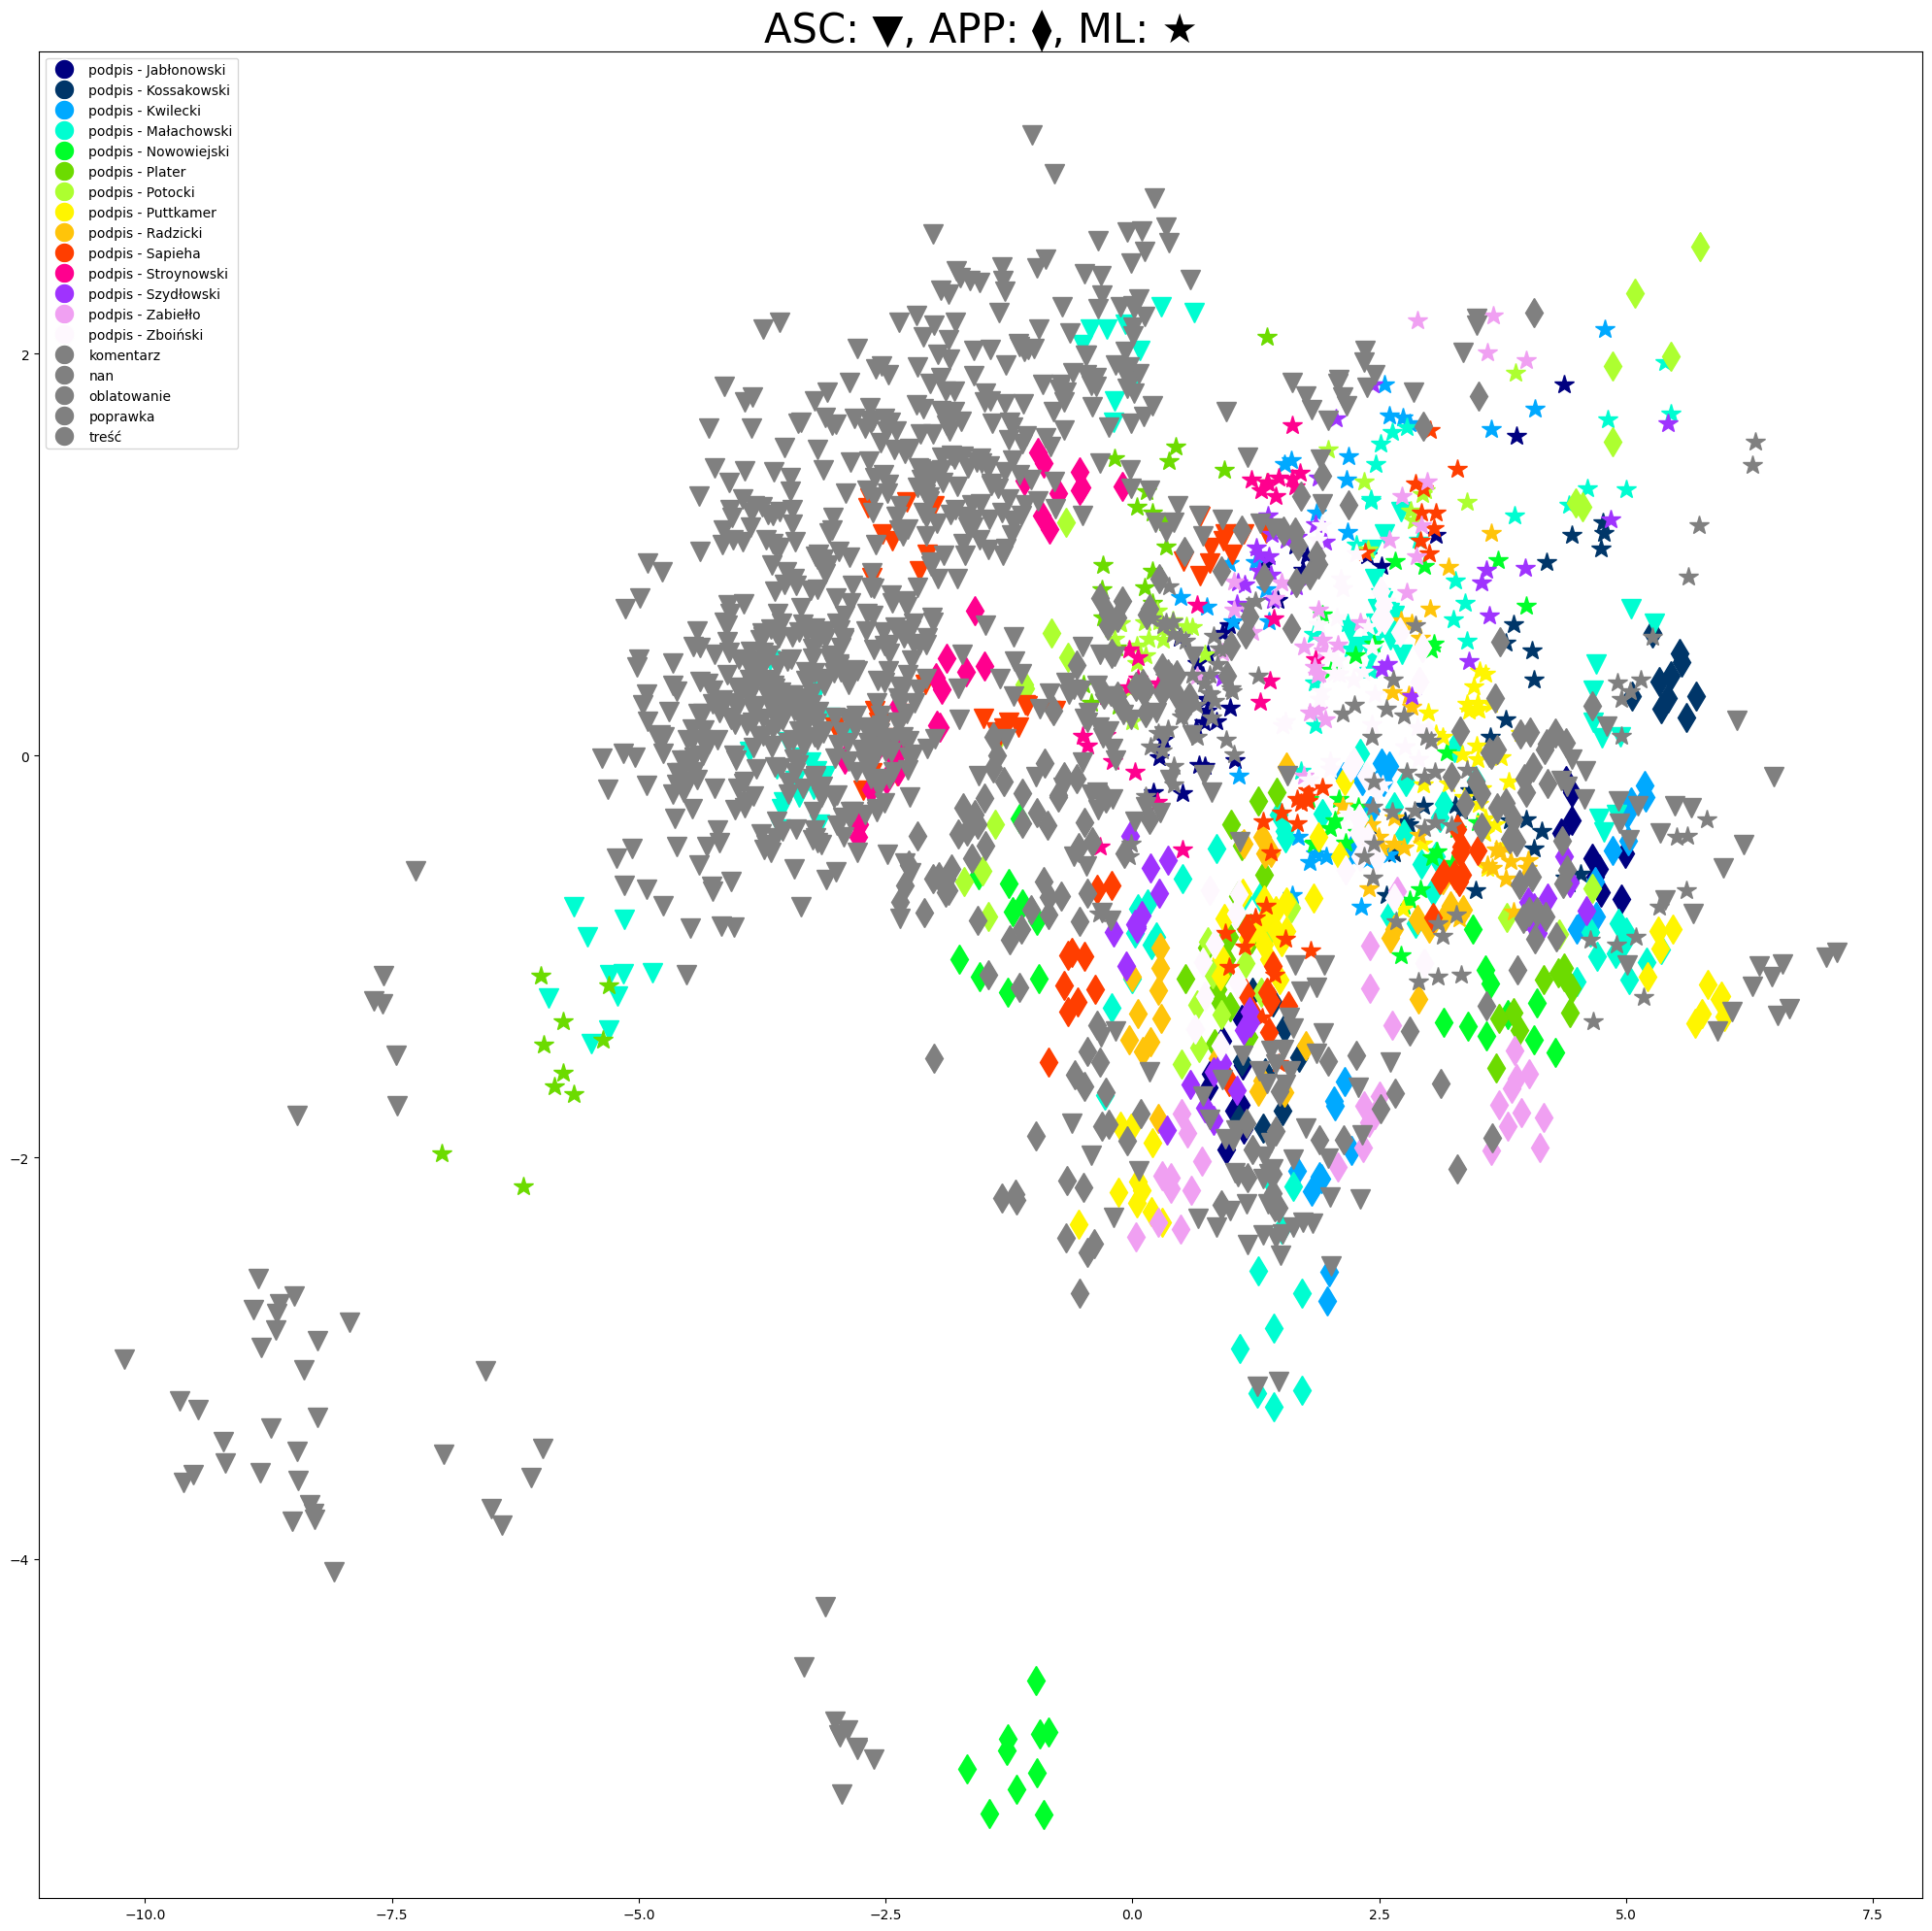

In [23]:
annotate = False

color = cm.gist_ncar(np.linspace(0, 1, len(signatures)))
grays = np.concatenate([np.array([0.5, 0.5, 0.5, 1]).reshape(1,-1) for _ in range(len(other))], axis=0)
color = np.concatenate([color, grays])

legend_elements = []
    
for label_nr, label in enumerate(signatures + other):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    current_codes = [class_df['Code'][i] for i in range(X_pca.shape[0]) if y[i] == label]
    if book_name == 'all':
        for nr in range(len(x_pca_0)):
            if nr == 0:
                legend_elements.append(Line2D([0], [0], color='w', marker='o', markerfacecolor=color[label_nr],
                                              label=label, markersize=15))
            plt.plot(x_pca_0[nr], x_pca_1[nr], marker=[marker_shapes[cc[:2]] for cc in current_codes][nr], 
                         color=color[label_nr], markersize=15)
    else:
        plt.plot(x_pca_0, x_pca_1, marker='o', label = label, color=color[label_nr], markersize=15)
    
for i in range(X_pca.shape[0]):
    if annotate:
        ann = class_df['Code'][i]
        plt.annotate(ann, (X_pca[i, 0], X_pca[i,1]), size=20)
if book_name == 'all':
    plt.legend(handles=legend_elements)
    plt.title('ASC: ' + '\u25BC' + ', APP: ' + '\u29EB' + ', ML: ' + '\u2605', fontsize=30)
else:
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.gcf().set_size_inches((20,20))
plt.tight_layout()
plt.savefig(figures_path + dataset + '_pca_' + book_name + '_annotate_' + str(annotate) + '.png')

### PCA - means of classes

In [24]:
# from sklearn.decomposition import PCA

# n_components = 2
# pca = PCA(n_components=n_components)
# X_pca = pca.fit_transform(X)

In [25]:
# temp_df = class_df
# temp_df['PC_0'] = X_pca[:,0]
# temp_df['PC_1'] = X_pca[:,1]

# means_df = class_df[['Code', 'Class name']].drop_duplicates()

In [26]:
# for pc_nr in range(n_components):
#     means_df['PC_' + str(pc_nr)] = temp_df.groupby('Code')['PC_' + str(pc_nr)].transform('mean')

In [27]:
# X_pca_mean = means_df[['PC_' + str(nr) for nr in range(n_components)]].values
# y_mean = list(means_df['Class name'])

In [28]:
#%matplotlib widget

In [29]:
# signatures = [word for word in sorted(list(set(y_mean))) if 'podpis' in word]
# other = sorted(list(set(y_mean).difference(set(signatures))))

In [30]:
# annotate = False

# color = cm.gist_ncar(np.linspace(0, 1, len(signatures)))
# grays = np.concatenate([np.array([0.5, 0.5, 0.5, 1]).reshape(1,-1) for _ in range(len(other))], axis=0)
# color = np.concatenate([color, grays])
    
# for label_nr, label in enumerate(signatures + other):
#     x_pca_0 = [X_pca_mean[i, 0] for i in range(X_pca_mean.shape[0]) if y_mean[i] == label]
#     x_pca_1 = [X_pca_mean[i,1] for i in range(X_pca_mean.shape[0]) if y_mean[i] == label]
#     plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr], markersize=15)
    
# for i in range(X_pca_mean.shape[0]):
#     if annotate:
#         ann = means_df['Code'].iloc[i]
#         plt.annotate(ann, (X_pca_mean[i, 0], X_pca_mean[i,1]), size=20)
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# plt.gcf().set_size_inches((20,20))
# plt.tight_layout()
#plt.savefig(figures_path + dataset + '_pca_' + book_name + '_means' + '_annotate_' + str(annotate) + '.png')

### PCA - representatives

### tSNE - all points

In [31]:
from sklearn.manifold import TSNE

n_components = 2
tsne = TSNE(n_components=n_components, random_state=42)
X_tsne = tsne.fit_transform(X)

In [32]:
#%matplotlib widget

In [33]:
signatures = [word for word in sorted(list(set(y))) if 'podpis' in word]
other = sorted(list(set(y).difference(set(signatures))))

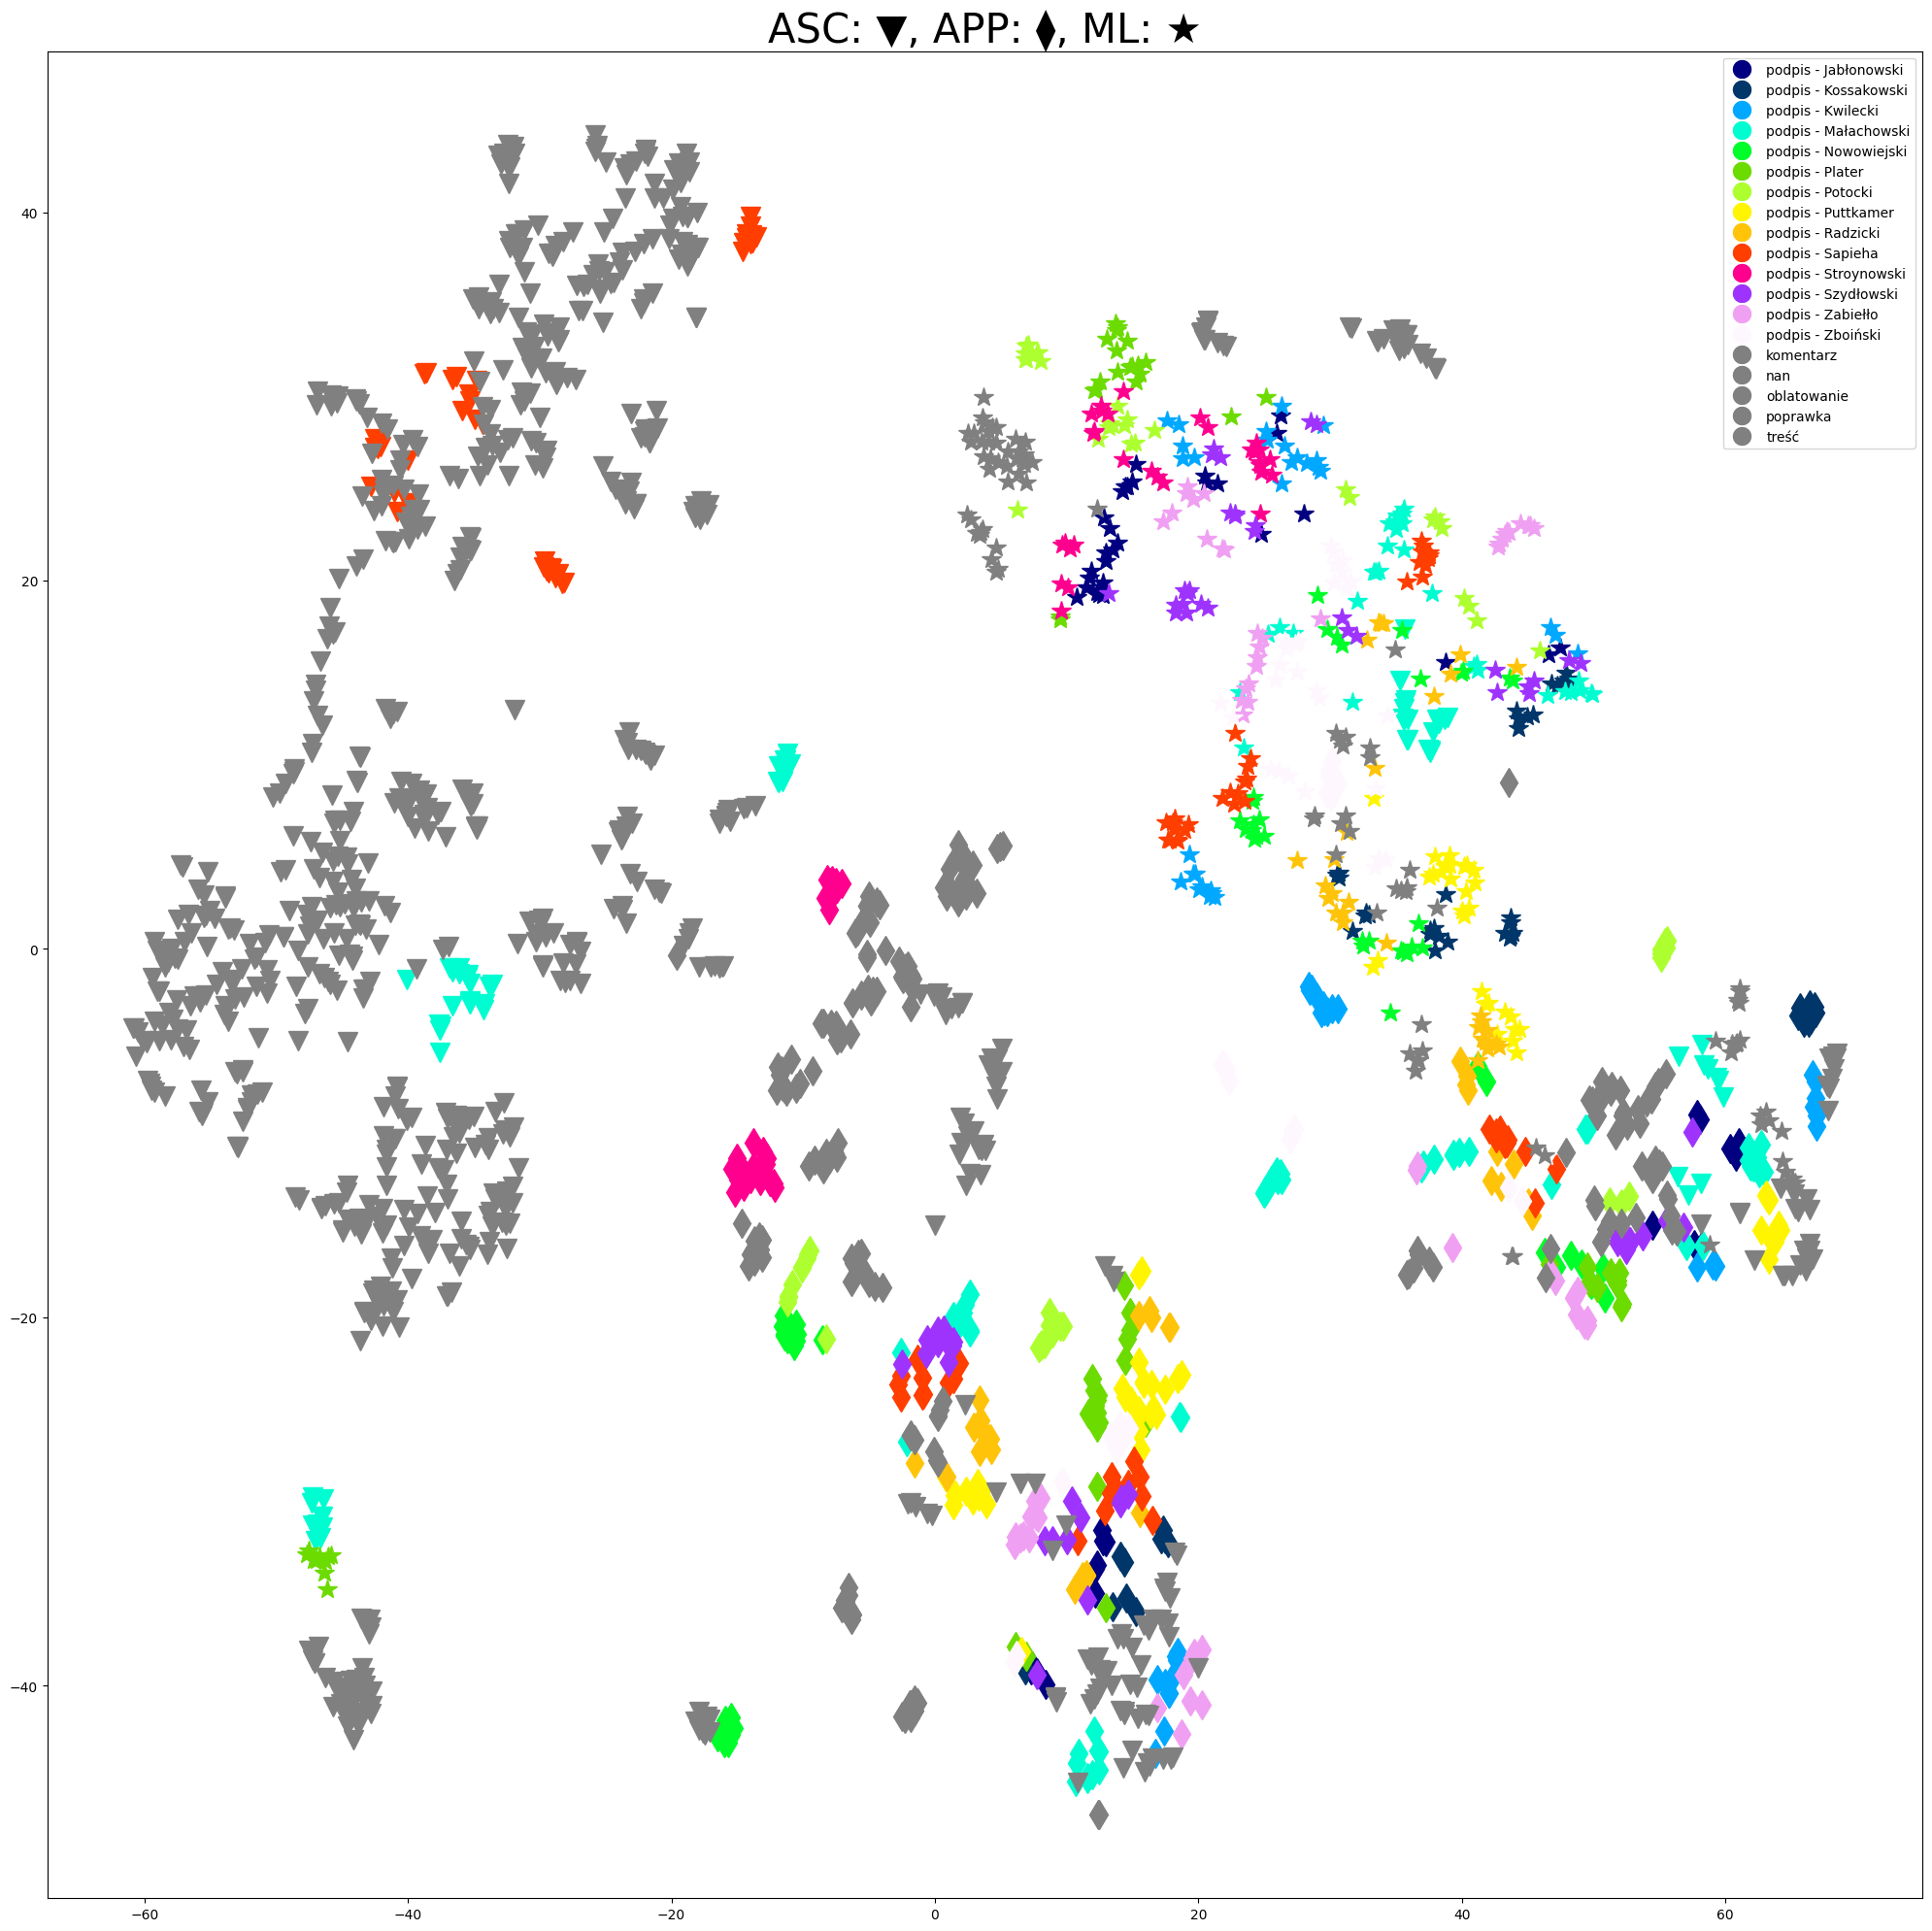

In [34]:
annotate = False

color = cm.gist_ncar(np.linspace(0, 1, len(signatures)))
grays = np.concatenate([np.array([0.5, 0.5, 0.5, 1]).reshape(1,-1) for _ in range(len(other))], axis=0)
color = np.concatenate([color, grays])

legend_elements = []
    
for label_nr, label in enumerate(signatures + other):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i, 1] for i in range(X_tsne.shape[0]) if y[i] == label]
    current_codes = [class_df['Code'][i] for i in range(X_tsne.shape[0]) if y[i] == label]
    if book_name == 'all':
        for nr in range(len(x_tsne_1)):
            if nr == 0:
                legend_elements.append(Line2D([0], [0], color='w', marker='o', markerfacecolor=color[label_nr],
                                              label=label, markersize=15))
            plt.plot(x_tsne_0[nr], x_tsne_1[nr], marker=[marker_shapes[cc[:2]] for cc in current_codes][nr], 
                         color=color[label_nr], markersize=15)
    else:
        plt.plot(x_tsne_0, x_tsne_1, marker='o', label = label, color=color[label_nr], markersize=15)
    
for i in range(X_tsne.shape[0]):
    if annotate:
        ann = class_df['Code'][i]
        plt.annotate(ann, (X_tsne[i, 0], X_tsne[i,1]), fontsize=20)
if book_name == 'all':
    plt.legend(handles=legend_elements)
    plt.title('ASC: ' + '\u25BC' + ', APP: ' + '\u29EB' + ', ML: ' + '\u2605', fontsize=30)
else:
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.gcf().set_size_inches((20,20))
plt.tight_layout()
plt.savefig(figures_path + dataset + '_tsne_' + book_name + '_annotate_' + str(annotate) + '.png')

- drawing random records from the same group?

### tSNE - means of classes

In [35]:
# from sklearn.manifold import TSNE

# n_components = 2
# tsne = TSNE(n_components=n_components, random_state=42)
# X_tsne = tsne.fit_transform(X)

In [36]:
# temp_df = class_df
# temp_df['tSNE_dim_0'] = X_tsne[:,0]
# temp_df['tSNE_dim_1'] = X_tsne[:,1]

# means_df = class_df[['Code', 'Class name']].drop_duplicates()

In [37]:
# for tsne_nr in range(n_components):
#     means_df['tSNE_dim_' + str(tsne_nr)] = temp_df.groupby('Code')['tSNE_dim_' + str(tsne_nr)].transform('mean')

In [38]:
# X_tsne_mean = means_df[['tSNE_dim_' + str(nr) for nr in range(n_components)]].values
# y_mean = list(means_df['Class name'])

In [39]:
# signatures = [word for word in sorted(list(set(y_mean))) if 'podpis' in word]
# other = sorted(list(set(y_mean).difference(set(signatures))))

In [40]:
# annotate = False

# color = cm.gist_ncar(np.linspace(0, 1, len(signatures)))
# grays = np.concatenate([np.array([0.5, 0.5, 0.5, 1]).reshape(1,-1) for _ in range(len(other))], axis=0)
# color = np.concatenate([color, grays])
    
# for label_nr, label in enumerate(signatures + other):
#     x_tsne_0 = [X_tsne_mean[i, 0] for i in range(X_tsne_mean.shape[0]) if y_mean[i] == label]
#     x_tsne_1 = [X_tsne_mean[i,1] for i in range(X_tsne_mean.shape[0]) if y_mean[i] == label]
#     plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr], markersize=15)
    
# for i in range(X_tsne_mean.shape[0]):
#     if annotate:
#         ann = means_df['Code'].iloc[i]
#         plt.annotate(ann, (X_tsne_mean[i, 0], X_tsne_mean[i,1]), size=20)
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# plt.gcf().set_size_inches((20,20))
# plt.tight_layout()
#plt.savefig(figures_path + dataset + '_tsne_' + book_name + '_means' + '_annotate_' + str(annotate) + '.png')

In [41]:
################################################